# Week 2 - Baseline Experiments

This notebook is a standalone Week 2 baseline for the project **Robust Federated Learning Against Adversarial Attacks**. It does not import or depend on any existing project source files. The baseline implements a minimal Federated Averaging (FedAvg) experiment directly in the notebook using the local CheXpert data in `data/`.

In [10]:
from pathlib import Path
import random

from IPython import get_ipython
from IPython.display import display
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic('matplotlib', 'inline')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for path in [start, *start.parents]:
        if (path / 'data' / 'raw' / 'train.csv').exists():
            return path
    raise FileNotFoundError('Could not find data/raw/train.csv from the current directory.')

ROOT = find_project_root()
RAW_DIR = ROOT / 'data' / 'raw'
CSV_PATH = RAW_DIR / 'train.csv'
TARGET = 'Cardiomegaly'

df = pd.read_csv(CSV_PATH)
df = df[df['Frontal/Lateral'] == 'Frontal'].copy()
df[TARGET] = df[TARGET].replace(-1, 0).fillna(0).astype(int)
df['patient_id'] = df['Path'].str.extract(r'patient(\d+)')[0]
df[[TARGET, 'Path', 'patient_id']].head()

,Cardiomegaly,Path,patient_id
0,0,CheXpert-v1.0-small/train/patient00001/study1/...,00001
1,0,CheXpert-v1.0-small/train/patient00002/study2/...,00002
2,0,CheXpert-v1.0-small/train/patient00002/study1/...,00002
4,0,CheXpert-v1.0-small/train/patient00003/study1/...,00003
5,0,CheXpert-v1.0-small/train/patient00004/study1/...,00004


## Baseline Setup

The project topic is Federated Learning, so the simplest topic-specific baseline is **FedAvg**. This notebook uses a larger natural-distribution CheXpert sample for the binary target `Cardiomegaly`, trains a small MLP through FedAvg, and runs 20 communication rounds.

The target is imbalanced, so accuracy can exceed 0.8 mostly because negative cases are common. For that reason, the notebook also reports balanced accuracy, F1, AUROC, average precision, the confusion matrix, ROC curve, and precision-recall curve.

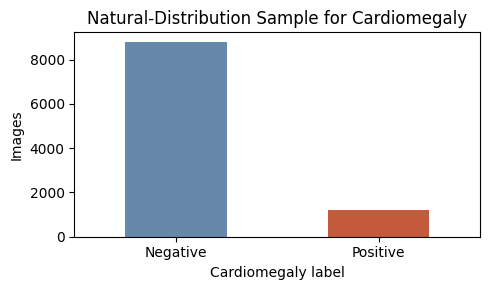

Sample size: 10,000
Positive rate: 0.120


Cardiomegaly
0    8795
1    1205
Name: count, dtype: int64

In [11]:
SAMPLE_SIZE = 10_000
IMAGE_SIZE = 32
NUM_CLIENTS = 5
ROUNDS = 20
LOCAL_EPOCHS = 1
BATCH_SIZE = 128
LEARNING_RATE = 0.001

sample = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)

target_counts = sample[TARGET].value_counts().sort_index()
ax = target_counts.plot(kind='bar', color=['#6688aa', '#c45a3c'], figsize=(5, 3))
ax.set_title(f'Natural-Distribution Sample for {TARGET}')
ax.set_xlabel(f'{TARGET} label')
ax.set_ylabel('Images')
ax.set_xticklabels(['Negative', 'Positive'], rotation=0)
plt.tight_layout()
fig = ax.get_figure()
display(fig)
plt.close(fig)

print(f'Sample size: {len(sample):,}')
print(f'Positive rate: {sample[TARGET].mean():.3f}')
target_counts

In [12]:
def load_pixel_features(paths, image_size=32):
    features = []
    for rel_path in paths:
        image = Image.open(RAW_DIR / rel_path).convert('L').resize((image_size, image_size))
        arr = np.asarray(image, dtype=np.float32) / 255.0
        features.append(arr.ravel())
    return np.vstack(features)

X = load_pixel_features(sample['Path'], IMAGE_SIZE)
y = sample[TARGET].to_numpy().astype(np.float32)

train_idx, test_idx = train_test_split(
    np.arange(len(y)), test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X[train_idx]).astype(np.float32)
X_test = scaler.transform(X[test_idx]).astype(np.float32)
y_train = y[train_idx].astype(np.float32)
y_test = y[test_idx].astype(np.float32)

print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)
print('Test positive rate:', y_test.mean())

Train shape: (8000, 1024) Test shape: (2000, 1024)
Test positive rate: 0.1205


## Minimal FedAvg Implementation

The cells below implement FedAvg directly:

1. Split the training data into simulated clients.
2. Copy the current global model to each client.
3. Train locally for one epoch.
4. Average client model weights weighted by local sample count.
5. Evaluate the global model after each communication round.

A small MLP is used instead of a linear model so the baseline has more capacity while still remaining simple and fast.

In [13]:
class MLPImageClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

def make_clients(X_train, y_train, num_clients):
    indices = np.arange(len(y_train))
    np.random.default_rng(RANDOM_STATE).shuffle(indices)
    splits = np.array_split(indices, num_clients)
    clients = []
    for client_id, idx in enumerate(splits):
        x_client = torch.from_numpy(X_train[idx])
        y_client = torch.from_numpy(y_train[idx])
        clients.append((client_id, TensorDataset(x_client, y_client)))
    return clients

def local_train(global_model, client_dataset, epochs=1, batch_size=128, lr=0.001):
    local_model = MLPImageClassifier(X_train.shape[1])
    local_model.load_state_dict(global_model.state_dict())
    local_model.train()
    optimizer = torch.optim.Adam(local_model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()
    loader = DataLoader(client_dataset, batch_size=batch_size, shuffle=True)
    for _ in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(local_model(xb), yb)
            loss.backward()
            optimizer.step()
    return local_model.state_dict(), len(client_dataset)

def fedavg(client_states):
    total = sum(n for _, n in client_states)
    averaged = {}
    for key in client_states[0][0].keys():
        averaged[key] = sum(state[key] * (n / total) for state, n in client_states)
    return averaged

def predict_proba(model, X_array):
    model.eval()
    with torch.no_grad():
        logits = model(torch.from_numpy(X_array))
        return torch.sigmoid(logits).numpy()

def compute_metrics(y_true, proba):
    pred = (proba >= 0.5).astype(int)
    return {
        'accuracy': accuracy_score(y_true, pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, pred),
        'f1': f1_score(y_true, pred, zero_division=0),
        'auc': roc_auc_score(y_true, proba),
        'average_precision': average_precision_score(y_true, proba),
        'predicted_positive_rate': pred.mean(),
    }

client_0    1600
client_1    1600
client_2    1600
client_3    1600
client_4    1600
dtype: int64

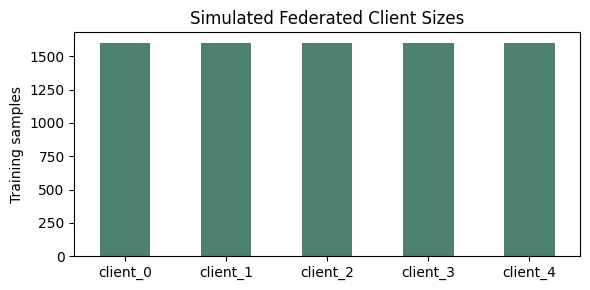

In [14]:
clients = make_clients(X_train, y_train, NUM_CLIENTS)
client_sizes = pd.Series({f'client_{cid}': len(ds) for cid, ds in clients})

ax = client_sizes.plot(kind='bar', figsize=(6, 3), color='#4f7f6f')
ax.set_title('Simulated Federated Client Sizes')
ax.set_ylabel('Training samples')
plt.xticks(rotation=0)
plt.tight_layout()
client_sizes

In [15]:
global_model = MLPImageClassifier(X_train.shape[1])
history = []

for round_id in range(1, ROUNDS + 1):
    client_states = []
    for _, client_dataset in clients:
        state, n_samples = local_train(
            global_model,
            client_dataset,
            epochs=LOCAL_EPOCHS,
            batch_size=BATCH_SIZE,
            lr=LEARNING_RATE,
        )
        client_states.append((state, n_samples))
    global_model.load_state_dict(fedavg(client_states))
    proba = predict_proba(global_model, X_test)
    metrics = compute_metrics(y_test, proba)
    metrics['round'] = round_id
    history.append(metrics)

history_df = pd.DataFrame(history).set_index('round')
history_df.round(4)

,accuracy,balanced_accuracy,f1,auc,average_precision,predicted_positive_rate
round,,,,,,
1,0.8780,0.4991,0.0000,0.6611,0.1871,0.0015
2,0.8780,0.4991,0.0000,0.6892,0.2181,0.0015
3,0.8775,0.5007,0.0081,0.7210,0.2510,0.0030
4,0.8800,0.5092,0.0400,0.7224,0.2563,0.0045
5,0.8800,0.5074,0.0323,0.7301,0.2645,0.0035
6,0.8785,0.5048,0.0241,0.7374,0.2767,0.0040
7,0.8805,0.5059,0.0245,0.7328,0.2693,0.0020
8,0.8800,0.5057,0.0244,0.7359,0.2795,0.0025
9,0.8790,0.5051,0.0242,0.7414,0.2827,0.0035


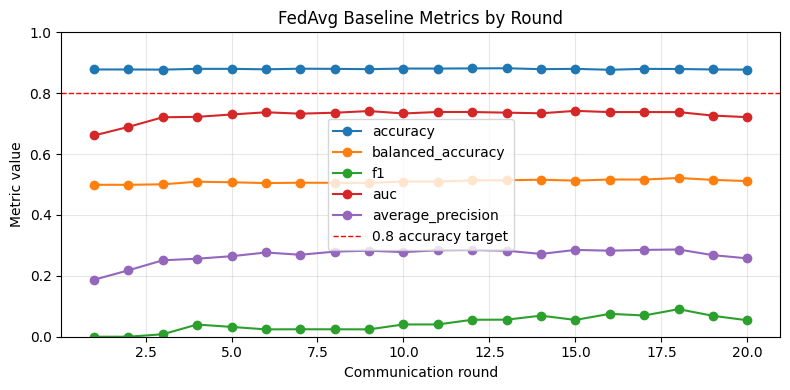

In [16]:
ax = history_df[['accuracy', 'balanced_accuracy', 'f1', 'auc', 'average_precision']].plot(
    figsize=(8, 4), marker='o'
)
ax.axhline(0.8, color='red', linestyle='--', linewidth=1, label='0.8 accuracy target')
ax.set_title('FedAvg Baseline Metrics by Round')
ax.set_xlabel('Communication round')
ax.set_ylabel('Metric value')
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend(loc='best')
plt.tight_layout()
fig = ax.get_figure()
display(fig)
plt.close(fig)


In [17]:
final_proba = predict_proba(global_model, X_test)
final_pred = (final_proba >= 0.5).astype(int)
final_metrics = compute_metrics(y_test, final_proba)
display(pd.Series(final_metrics).to_frame('FedAvg final value').round(4))
print(classification_report(y_test, final_pred, target_names=['Negative', 'Positive'], zero_division=0))
print(f'Final accuracy >= 0.8: {final_metrics["accuracy"] >= 0.8}')

,FedAvg final value
accuracy,0.8775
balanced_accuracy,0.5114
f1,0.0541
auc,0.7213
average_precision,0.2575
predicted_positive_rate,0.0090


              precision    recall  f1-score   support

    Negative       0.88      0.99      0.93      1759
    Positive       0.39      0.03      0.05       241

    accuracy                           0.88      2000
   macro avg       0.64      0.51      0.49      2000
weighted avg       0.82      0.88      0.83      2000

Final accuracy >= 0.8: True


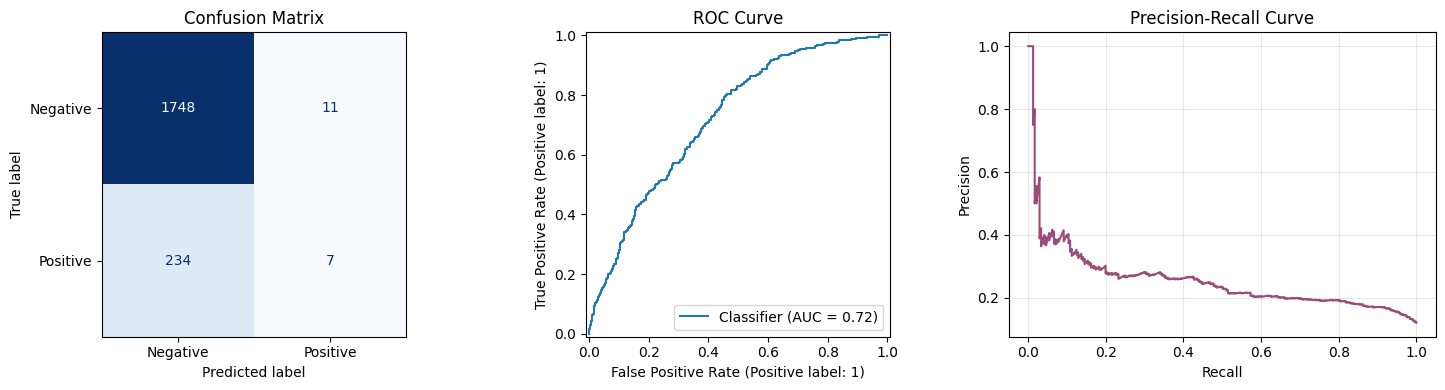

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, final_pred), display_labels=['Negative', 'Positive']).plot(
    ax=axes[0], colorbar=False, cmap='Blues'
)
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, final_proba, ax=axes[1])
axes[1].set_title('ROC Curve')

precision, recall, _ = precision_recall_curve(y_test, final_proba)
axes[2].plot(recall, precision, color='#9a4d7a')
axes[2].set_title('Precision-Recall Curve')
axes[2].set_xlabel('Recall')
axes[2].set_ylabel('Precision')
axes[2].grid(alpha=0.3)

plt.tight_layout()